In [1]:
import torch
import torch.nn as nn

import numpy as np
import xtrack as xt
import xpart as xp
import xobjects as xo
import matplotlib.pyplot as plt
import pickle
from datetime import datetime

from scipy import stats
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

torch.set_default_dtype(torch.float64)

In [2]:
class DeepONet(nn.Module):
    def __init__(self, branch_net, trunk_net, branch_dim=2):
        super(DeepONet, self).__init__()
        self.branch_net = branch_net
        self.trunk_net = trunk_net
        self.branch_dim = branch_dim
    
    def forward(self, x):
        qp = x[:, :self.branch_dim]
        time = x[:, self.branch_dim:]
        
        bases = self.branch_net(qp)
        coefficients = self.trunk_net(time)

        return bases * coefficients

        
def init_weights_glorot(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def normalize(x, minimum=None, maximum=None):
    if minimum is None:
        minimum = x.min()
    if maximum is None:
        maximum = x.max()
    return (x - minimum) / (maximum - minimum)

### Data generation

In [4]:
ctx= xo.ContextCpu()
line = xt.Line.from_json('sequence/ps_ft_tof.json')
line.build_tracker(_context=ctx)    

tw = line.twiss(method='4d')

Loading line from dict: 100%|██████████| 5796/5796 [00:00<00:00, 6812.20it/s]


Done loading line from dict.           


In [72]:
initial_k1f = line['k1prpfwf']
initial_k1d = line['k1prpfwd']

In [ ]:
np.random.seed(144)
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))

parameters = [6.4034, 6.3501, 6.2703]

n_turns = 10000
record_every = 100
num_particles = 10000
y = np.zeros((num_particles, n_turns//record_every + 1))
py = np.zeros((num_particles, n_turns//record_every + 1))

data_y = []
data_py = []
start_time = datetime.now()
for j in range(len(parameters)):
    line['k1prpfwf'] = initial_k1f
    line['k1prpfwd'] = initial_k1d

    line.match(
            method='4d',
            vary=[
                xt.VaryList(['k1prpfwf'], step=1e-8, tag='quad'),
                xt.VaryList(['k1prpfwd'], step=1e-8, tag='quad'),
            ],
            targets = [
                xt.TargetSet(qx=6.13022, tol=1e-6, tag='tune'),
                xt.TargetSet(qy=parameters[j], tol=1e-6, tag='tune'),
            ])

    final_k1f = line['k1prpfwf']
    final_k1d = line['k1prpfwd']

    line['k1prpfwf'] = initial_k1f
    line['k1prpfwd'] = initial_k1d
    
    y_in_sigmas, py_in_sigmas = xp.generate_2D_gaussian(num_particles)

    particles = line.build_particles(
                y_norm=y_in_sigmas, py_norm=py_in_sigmas,
                nemitt_y=8e-6, method = "4d")

    y[:, 0] = particles.y
    py[:, 0] = particles.py
    for i in range(n_turns):
        line['k1prpfwf'] = initial_k1f + (final_k1f - initial_k1f) * i / n_turns
        line['k1prpfwd'] = initial_k1d + (final_k1d - initial_k1d) * i / n_turns
        line.track(particles, num_turns=1, freeze_longitudinal=True)

        if (i+1) % record_every == 0:
            y[:, (i+1)//record_every] = particles.y
            py[:, (i+1)//record_every] = particles.py

    

    data_y.append(y.copy())
    data_py.append(py.copy())

end_time = datetime.now()

print(end_time - start_time)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
                                             
Optimize - start penalty: 0.0002524                         
Matching: model call n. 5 penalty = 2.6821e-09              
Optimize - end penalty:  2.68214e-09                            
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
                                             
Optimize - start penalty: 0.5328                            
Matching: model call n. 9 penalty = 1.3490e-08              
Optimize - end penalty:  1.34903e-08                            


In [ ]:
#with open('data/density_ps_10k.pkl', 'wb') as f:
#    pickle.dump((data_y, data_py, parameters), f)

In [3]:
pi = np.pi
lbend = 3

# Create an environment
env = xt.Environment()

env['k1f'] = 0.1
env['k1d'] = -0.7

# Build a simple ring
line = env.new_line(components=[
    env.new('mqf.1', xt.Quadrupole, length=0.3, k1='k1f'),
    env.new('d1.1',  xt.Drift, length=1),
    env.new('mb1.1', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d2.11',  xt.Drift, length=0.3),
    env.new('mof.1', xt.Octupole, length=0.4, k3=0.0), # octupolar perturbation
    env.new('d2.12',  xt.Drift, length=0.3),

    env.new('mqd.1', xt.Quadrupole, length=0.3, k1='k1d'),
    env.new('d3.1',  xt.Drift, length=1),
    env.new('mb2.1', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d4.1',  xt.Drift, length=1),

    env.new('mqf.2', xt.Quadrupole, length=0.3, k1='k1f'),
    env.new('d1.2',  xt.Drift, length=1),
    env.new('mb1.2', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d2.2',  xt.Drift, length=1),

    env.new('mqd.2', xt.Quadrupole, length=0.3, k1='k1d'),
    env.new('d3.2',  xt.Drift, length=1),
    env.new('mb2.2', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d4.2',  xt.Drift, length=1),
])

# Define reference particle
line.particle_ref = xt.Particles(p0c=1.2e9, mass0=xt.PROTON_MASS_EV)

In [4]:
initial_k1f = line['k1f']
initial_k1d = line['k1d']

In [5]:
np.random.seed(144)
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))

parameters = [0.5095, 0.61, 0.71]

n_turns = 10000
record_every = 100
num_particles = 10000
y = np.zeros((num_particles, n_turns//record_every + 1))
py = np.zeros((num_particles, n_turns//record_every + 1))

data_y = []
data_py = []
start_time = datetime.now()
for j in range(len(parameters)):
    line['k1f'] = initial_k1f
    line['k1d'] = initial_k1d

    line.match(
            method='4d',
            vary=[
                xt.VaryList(['k1f'], step=1e-8, tag='quad'),
                xt.VaryList(['k1d'], step=1e-8, tag='quad'),
            ],
            targets = [
                xt.TargetSet(qx=1.36, tol=1e-6, tag='tune'),
                xt.TargetSet(qy=parameters[j], tol=1e-6, tag='tune'),
            ])

    final_k1f = line['k1f']
    final_k1d = line['k1d']

    line['k1f'] = initial_k1f
    line['k1d'] = initial_k1d
    
    y_in_sigmas, py_in_sigmas = xp.generate_2D_gaussian(num_particles)

    particles = line.build_particles(
                y_norm=y_in_sigmas, py_norm=py_in_sigmas,
                nemitt_y=13e-6, method = "4d")

    y[:, 0] = particles.y
    py[:, 0] = particles.py
    for i in range(n_turns):
        line['k1f'] = initial_k1f + (final_k1f - initial_k1f) * i / n_turns
        line['k1d'] = initial_k1d + (final_k1d - initial_k1d) * i / n_turns
        line.track(particles, num_turns=1, freeze_longitudinal=True)

        if (i+1) % record_every == 0:
            y[:, (i+1)//record_every] = particles.y
            py[:, (i+1)//record_every] = particles.py

    

    data_y.append(y.copy())
    data_py.append(py.copy())

end_time = datetime.now()

print(end_time - start_time)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
                                             
Optimize - start penalty: 0.04295                           
Matching: model call n. 18 penalty = 8.7233e-07              
Optimize - end penalty:  8.72328e-07                            
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
                                             
Optimize - start penalty: 1.006                             
Matching: model call n. 17 penalty = 6.6480e-06              
Optimize - end penalty:  6.64804e-06                            
                                             
Optimize - start penalty: 2.005                             
Matching: model call n. 18 penalty = 2.7957e-06              
Optimize - end penalty:  2.79568e-06                            
3:35:48.731933


In [8]:
with open('data/density_10k.pkl', 'wb') as f:
    pickle.dump((data_y, data_py, parameters), f)

### DeepONet

In [26]:
#with open('data/density.pkl', 'rb') as f:
#with open('data/density_ps.pkl', 'rb') as f:
with open('data/density_10k.pkl', 'rb') as f:
    data_y, data_py, parameters = pickle.load(f)

EOFError: Ran out of input

In [25]:
print(data_y[0].shape)

(1000, 101)


In [38]:
for i in range(len(data_y)):
    print(np.min(data_y[i]))
    print(np.max(data_y[i]))

    print(np.min(data_py[i]))
    print(np.max(data_py[i]))

-0.007822489217552391
0.007807814037902816
-0.0006655867133353536
0.0006651958809009604
-0.008381372553352856
0.008380879984077614
-0.0007093602671185871
0.0007064994437858768
-0.007963238291359925
0.007966842698796776
-0.0006681612463558553
0.0006704516176226794


In [39]:
print(data_y[0][:, 0].shape)

(1000,)


In [44]:
histograms = []
for i in range(len(data_y)):
    tmp = []
    for j in range(data_y[i].shape[1]): # iterate over turns
        hist = np.histogram2d(data_y[i][:, j], data_py[i][:, j], bins=32, range=[[-0.008, 0.008], [-0.0007, 0.0007]], density=False, weights=None)
        tmp.append(hist)
    histograms.append(tmp)

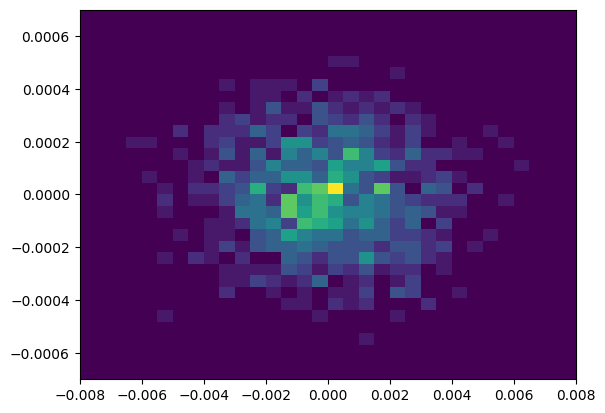

In [45]:
plt.pcolormesh(histograms[0][0][1], histograms[0][0][2], histograms[0][0][0])

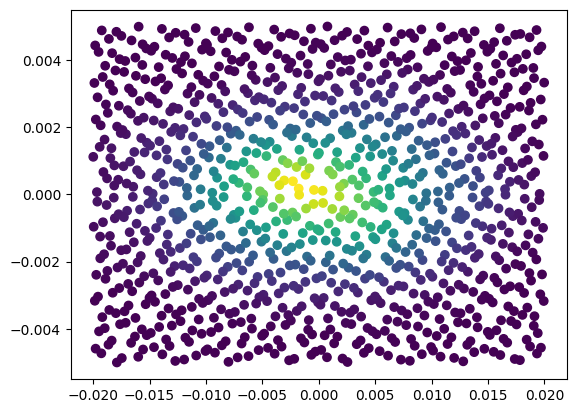

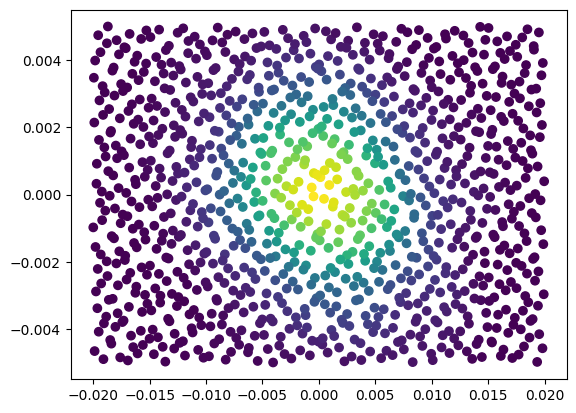

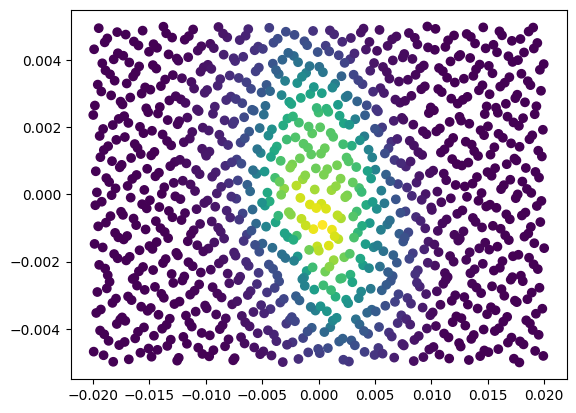

In [17]:
from sklearn.neighbors import KernelDensity

densities = []
positions = []
for i in range(len(data_y)):
    tmp = []
    pos_tmp = []
    for j in range(data_y[i].shape[1]): # iterate over turns
        soboleng = torch.quasirandom.SobolEngine(dimension=2, scramble=True)
        gridpoints = soboleng.draw(1024)
        gridpoints[:, 0] = (2 * gridpoints[:, 0] - 1) * 0.02   # 0.028 for simple line, 0.008 for PS
        gridpoints[:, 1] = (2 * gridpoints[:, 1] - 1) * 0.005  # 0.007 for simple line, 0.0007 for PS
        gridpoints = gridpoints.permute(1, 0)

        values = np.vstack([data_y[i][:, j], data_py[i][:, j]])
        kde = stats.gaussian_kde(values)
        density = kde(gridpoints)

        gridpoints = gridpoints.permute(1, 0)

        tmp.append(density)
        positions.append(gridpoints)

    plt.scatter(gridpoints[:, 0], gridpoints[:, 1], c=density, cmap='viridis')
    plt.show()    
    densities.append(tmp)

In [18]:
# there are only three unique input densities
inputs_branch = []
targets = []
for i in range(len(densities)):
    inputs_branch.append(parameters[i])
    targets.append(np.expand_dims(np.hstack(densities[i]), 1))

targets = np.vstack(targets)

inputs_branch = np.repeat(inputs_branch, densities[0][0].shape[0] * len(densities[0]))
inputs_branch = np.expand_dims(inputs_branch, 1)

inputs_trunk = np.vstack(positions)
t = np.linspace(0, 1, len(densities[0]))
t = np.repeat(t, densities[0][0].shape[0])
t = np.tile(np.expand_dims(t, 1), (len(densities), 1))
inputs_trunk = np.hstack([inputs_trunk, t])

inputs = np.hstack([inputs_branch, inputs_trunk])

In [ ]:
'''
idx = 2
inputs_branch = np.expand_dims(densities[idx][0], 0)
inputs_trunk = np.tile(positions.T, (data_y[idx].shape[1], 1))

t = np.linspace(0, 1, len(densities[idx]))
t = np.repeat(t, densities[idx][0].shape[0])
inputs_trunk = np.hstack([inputs_trunk, np.expand_dims(t, 1)])

targets = np.expand_dims(np.hstack(densities[idx]), 1)

print(inputs_branch.shape)
print(inputs_trunk.shape)
print(targets.shape)
'''

(103424,)
(103424, 2)
(1, 1024)
(103424, 3)
(103424, 1)


In [19]:
#inputs_branch = torch.tensor(inputs_branch)
#inputs_trunk = torch.tensor(inputs_trunk)
#targets = torch.tensor(targets)

inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

In [ ]:
'''
inputs_branch = normalize(inputs_branch)
for row in range(inputs_trunk.shape[1]):
    inputs_trunk[:, row] = normalize(inputs_trunk[:, row])

targets = normalize(targets)
'''

In [20]:
for row in range(inputs.shape[1]):
    inputs[:, row] = normalize(inputs[:, row])

targets = normalize(targets)

In [50]:
batch_size = 64

dataset = TensorDataset(inputs, targets)
#trainset = torch.utils.data.Subset(dataset, np.random.choice(np.linspace(0, inputs_trunk.shape[0]-1, inputs_trunk.shape[0]).astype(int), int(inputs_trunk.shape[0] * 0.2), replace=False))
trainset = torch.utils.data.Subset(dataset, np.random.choice(np.linspace(0, inputs.shape[0]-1, inputs.shape[0]).astype(int), int(inputs.shape[0] * 0.2), replace=False))
data_loader = DataLoader(trainset, batch_size, True)

In [51]:
full_set = TensorDataset(inputs, targets)
test_loader = DataLoader(full_set, batch_size, False)

In [52]:
from models import *

branch_net =  ResidualNet(1, 64, 64, num_blocks=3, activation=F.relu)
trunk_net = ResidualNet(3, 64, 64, num_blocks=5, activation=F.relu)

#branch_net =  MLP(1024, [512, 256], 32, 'relu')
#trunk_net = MLP(3, [64, 64, 64], 32, 'relu')

model = DeepONet(branch_net, trunk_net, 1, 1, 64)

# use Glorot initialisation
model.apply(init_weights_glorot)

DeepONet(
  (branch_net): ResidualNet(
    (initial_layer): Linear(in_features=1, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-2): 3 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
  (trunk_net): ResidualNet(
    (initial_layer): Linear(in_features=3, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-4): 5 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [53]:
branch = torch.randn(1, 1)          # example image input
trunk = torch.randn(1, 3)        # example image input
print(summary(branch_net, input_data={'inputs': torch.randn(1, 1) }))
print(summary(trunk_net, input_data={'inputs': torch.randn(1, 3) }))

Layer (type:depth-idx)                   Output Shape              Param #
ResidualNet                              [1, 64]                   --
├─Linear: 1-1                            [1, 64]                   128
├─ModuleList: 1-2                        --                        --
│    └─ResidualBlock: 2-1                [1, 64]                   --
│    │    └─ModuleList: 3-3              --                        (recursive)
│    │    └─Dropout: 3-2                 [1, 64]                   --
│    │    └─ModuleList: 3-3              --                        (recursive)
│    └─ResidualBlock: 2-2                [1, 64]                   --
│    │    └─ModuleList: 3-6              --                        (recursive)
│    │    └─Dropout: 3-5                 [1, 64]                   --
│    │    └─ModuleList: 3-6              --                        (recursive)
│    └─ResidualBlock: 2-3                [1, 64]                   --
│    │    └─ModuleList: 3-9              --     

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-4)

epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in data_loader:
        optimizer.zero_grad()
        x, y = batch
        
        #branch_output = branch_net(inputs_branch)
        #trunk_output = trunk_net(x)

        #outputs = torch.einsum('bi,bi->b', branch_output, trunk_output).unsqueeze(1)
        outputs = model(x)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(data_loader):.8f}")

In [ ]:
torch.save()

In [56]:
model.eval()
total_loss_test = []
max_loss = 0
for batch in test_loader:
    total_losses = 0
    with torch.no_grad():
        x, y = batch
        #branch_output = branch_net(inputs_branch)
        #trunk_output = trunk_net(x)
        outputs = model(x)

        #outputs = torch.einsum('bi, bi -> b', branch_output, trunk_output).unsqueeze(1)
        
        loss = torch.abs(outputs - y).max()
        
        if loss > max_loss:
            max_loss = loss
        #print(f"loss = {total_losses:.8f}")
        print(f"max loss = {loss:.8f}")
print(max_loss)

max loss = 0.07643548
max loss = 0.08122955
max loss = 0.15205654
max loss = 0.15488549
max loss = 0.06864005
max loss = 0.06403164
max loss = 0.11928610
max loss = 0.10583973
max loss = 0.07786775
max loss = 0.06345730
max loss = 0.07679397
max loss = 0.12675386
max loss = 0.11843340
max loss = 0.07214957
max loss = 0.09860086
max loss = 0.05817554
max loss = 0.19333887
max loss = 0.12118430
max loss = 0.14463909
max loss = 0.10710530
max loss = 0.12429196
max loss = 0.08067805
max loss = 0.14228603
max loss = 0.21045644
max loss = 0.20710676
max loss = 0.06736281
max loss = 0.10087102
max loss = 0.08858296
max loss = 0.18353271
max loss = 0.06893722
max loss = 0.13297917
max loss = 0.11956590
max loss = 0.10169532
max loss = 0.05608441
max loss = 0.11013226
max loss = 0.09527888
max loss = 0.09327522
max loss = 0.19058358
max loss = 0.17642079
max loss = 0.07377621
max loss = 0.12425779
max loss = 0.07587543
max loss = 0.19113414
max loss = 0.11176097
max loss = 0.09701627
max loss =

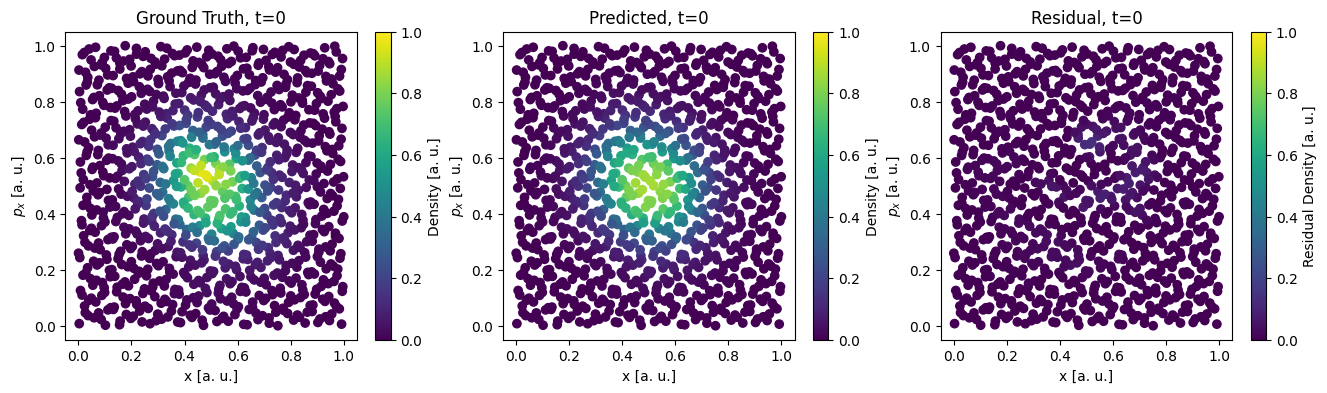

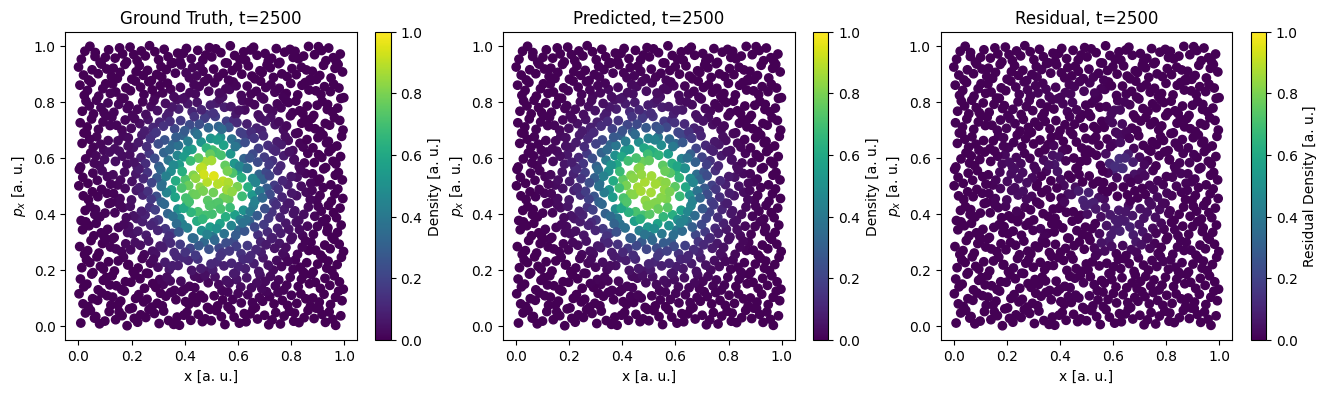

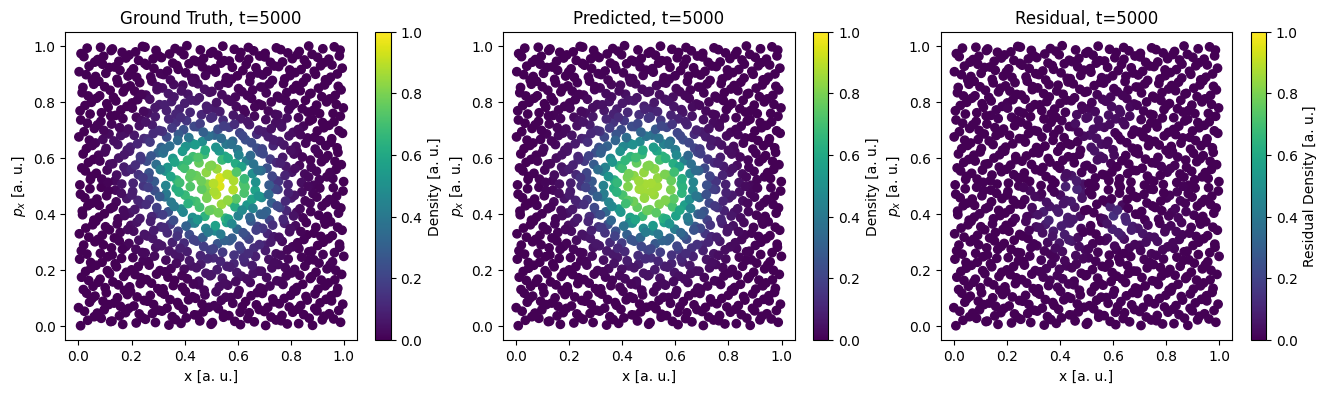

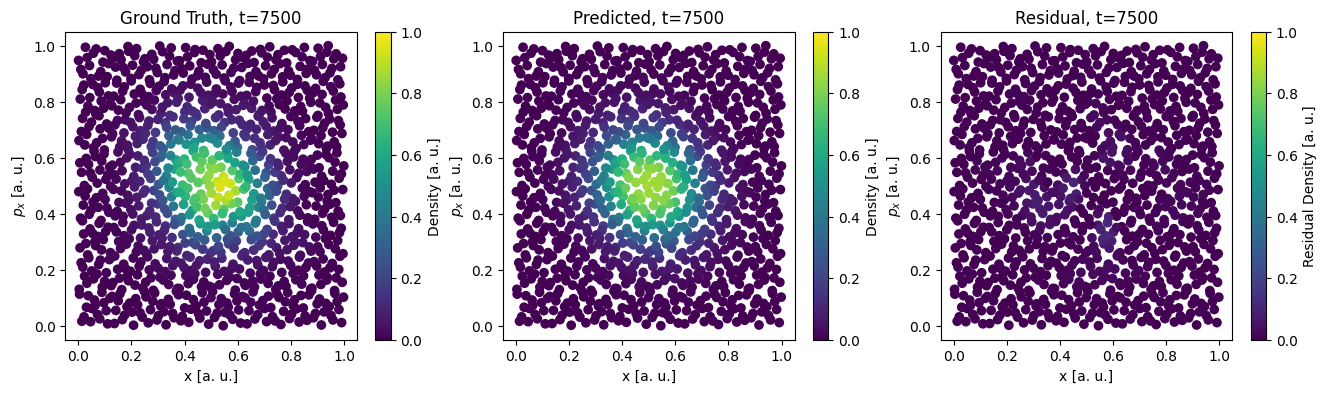

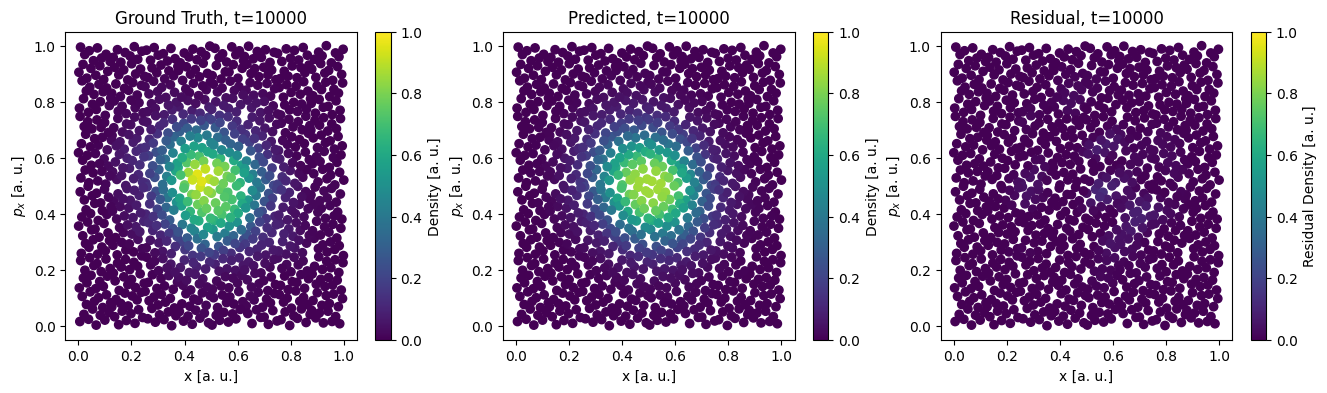

In [70]:
#for i in [0, 25, 50, 75, 100]:
#for i in [101, 125, 150, 175, 201]:
for j in [0, 25, 50, 75, 100]:
    i = j + 202
    with torch.no_grad():
        x = inputs[1024*i:1024*(i+1), :]
        #x = inputs_trunk[1024*i:1024*(i+1), :]
        y = targets[1024*i:1024*(i+1), :]
        #branch_output = branch_net(inputs_branch)
        #trunk_output = trunk_net(x)

        #outputs = torch.einsum('bi,bi -> b', branch_output, trunk_output).unsqueeze(1)
        outputs = model(x)
        difference = outputs - y

        #plt.pcolormesh(x[:, 0].view(32, 32), x[:, 1].view(32, 32), torch.abs(difference).view(32, 32))
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        sc = ax[0].scatter(x[:, 1], x[:, 2], c=y, cmap='viridis', vmin=0, vmax=1)
        ax[0].set_title(f'Ground Truth, t={j*100}')
        ax[0].set_xlabel('x [a. u.]')
        ax[0].set_ylabel(r'$p_x$ [a. u.]')
        cbar = fig.colorbar(sc, ax=ax[0])
        cbar.set_label('Density [a. u.]')
        sc = ax[1].scatter(x[:, 1], x[:, 2], c=outputs, cmap='viridis', vmin=0, vmax=1)
        cbar = fig.colorbar(sc, ax=ax[1])
        cbar.set_label('Density [a. u.]')
        ax[1].set_title(f'Predicted, t={j*100}')
        ax[1].set_xlabel('x [a. u.]')
        ax[1].set_ylabel(r'$p_x$ [a. u.]')
        sc = ax[2].scatter(x[:, 1], x[:, 2], c=difference, cmap='viridis', vmin=0, vmax=1)
        ax[2].set_title(f'Residual, t={j*100}')
        ax[2].set_xlabel('x [a. u.]')
        ax[2].set_ylabel(r'$p_x$ [a. u.]')
        cbar = fig.colorbar(sc, ax=ax[2])
        cbar.set_label('Residual Density [a. u.]')
        #ax[0].pcolormesh(x[:, 1].view(32, 32), x[:, 2].view(32, 32), y.view(32, 32))
        #ax[1].pcolormesh(x[:, 1].view(32, 32), x[:, 2].view(32, 32), outputs.view(32, 32))
        #ax[2].pcolormesh(x[:, 1].view(32, 32), x[:, 2].view(32, 32), difference.view(32, 32))

In [ ]:
print(x.shape)

In [101]:
print(branch_output.shape)
print(trunk_output.shape)

torch.Size([1, 32])
torch.Size([1024, 32])


In [107]:
outputs = torch.einsum('ij, kj -> k', branch_output, trunk_output)
print(outputs.shape)

torch.Size([1024])


In [98]:
print(outputs.shape)

torch.Size([1024, 32])


In [94]:
print(inputs_trunk[:1024, 2])

tensor([-1., -1., -1.,  ..., -1., -1., -1.])


In [ ]:
for loss in total_losses_test:

In [75]:
print(branch_output.shape)
print(trunk_output.shape)

torch.Size([1, 64])
torch.Size([128, 64])
